In [1]:
from collections import Counter
import gzip
import pathlib

import torch
import pandas as pd
import scipy
import numpy as np

import scanpy as sc
import anndata as ad
import gseapy

import seaborn as sns
import matplotlib.pyplot as plt

import flipcrow
import flipcrow.paths
import flipcrow.scp1644_mothership as mship

mps_device = torch.device("mps")

# sc.settings.verbosity = 0
import warnings
warnings.filterwarnings("ignore")

sc.set_figure_params(figsize=(10, 10))

%matplotlib inline

1.10.0rc2


In [2]:
scp1644_filter = ad.read_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_filter.h5ad")

In [3]:
# scp1644_tumor = mship.tumor_study(scp1644_filter)

In [4]:
# scp1644_tumor.write_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_tumor.h5ad")
scp1644_tumor = ad.read_h5ad(flipcrow.paths.DATA_PATH / "SCP1644" / "mship_scp1644_tumor.h5ad")

In [5]:
print(list((flipcrow.paths.DATA_PATH / "markergenes").glob("*")))

[PosixPath('/Users/daniel/git/flipcrow/data/markergenes/mmc2.xlsx'), PosixPath('/Users/daniel/git/flipcrow/data/markergenes/mmc3.xlsx'), PosixPath('/Users/daniel/git/flipcrow/data/markergenes/NIHMS687993-supplement-supp_data_2.xlsx'), PosixPath('/Users/daniel/git/flipcrow/data/markergenes/deKoning2021.xlsx'), PosixPath('/Users/daniel/git/flipcrow/data/markergenes/mmc4.xlsx'), PosixPath('/Users/daniel/git/flipcrow/data/markergenes/mmc3.pdf'), PosixPath('/Users/daniel/git/flipcrow/data/markergenes/mmc4.pdf')]


In [6]:
raw_cell_cycle = pd.read_excel(flipcrow.paths.DATA_PATH / "markergenes/NIHMS687993-supplement-supp_data_2.xlsx", sheet_name=1)

In [7]:
print(raw_cell_cycle)
import math
cell_cycle_markers = {col: [str(x).strip() for x in raw_cell_cycle.loc[:, col].to_list() if str(x) != 'nan'] for col in raw_cell_cycle.columns}
print(cell_cycle_markers)



            G1/S             S          G2/M            M        M/G1
0            ACD         ABCC5          ANLN         AHI1       AGFG1
1          ACYP1        ABHD10         AP3D1      AKIRIN2      AGPAT3
2        ADAMTS1      ANKRD18A      ARHGAP19      ANKRD40      AKAP13
3        ANKRD10         ASF1B         ARL4A         ANLN        AMD1
4          APEX2         ATAD2         ARMC1       ANP32B      ANP32E
..           ...           ...           ...          ...         ...
146          NaN           NaN           NaN        YWHAH         NaN
147          NaN           NaN           NaN       ZC3HC1         NaN
148          NaN           NaN           NaN          ZFX         NaN
149          NaN           NaN           NaN        ZMYM1         NaN
150          NaN           NaN           NaN       ZNF207         NaN

[151 rows x 5 columns]
{'G1/S': ['ACD', 'ACYP1', 'ADAMTS1', 'ANKRD10', 'APEX2', 'ARGLU1', 'ATAD2', 'BARD1', 'BRD7', 'C1orf63', 'C7orf41', 'C14orf142', 'CAPN7',

In [8]:
for k, v in cell_cycle_markers.items():
    result = sc.tl.score_genes(scp1644_tumor, v, score_name=f"{k}_score")

In [9]:
print(scp1644_tumor.obs['G1/S_score'])

Biopsy_PANFR0489_T1_AACCGAGAGTCC    0.092334
Biopsy_PANFR0489_T1_AACCGTACCATG    0.051771
Biopsy_PANFR0489_T1_AAGCGAGAGCTG   -0.068063
Biopsy_PANFR0489_T1_AAGGGTAGCCCT   -0.063729
Biopsy_PANFR0489_T1_AATAGCTGTGGA   -0.028873
                                      ...   
Biopsy_PANFR0635_T1_TTGGGTTCGCTG   -0.058199
Biopsy_PANFR0635_T1_TTGTCCTGACAG   -0.070543
Biopsy_PANFR0635_T1_TTGTGATGTACC   -0.024849
Biopsy_PANFR0635_T1_TTTATAAGGATC   -0.096450
Biopsy_PANFR0635_T1_TTTGGGATCTAC   -0.043100
Name: G1/S_score, Length: 6370, dtype: float64


In [17]:
print(scp1644_tumor.obs['G1/S_score'].mean() + 1.5*scp1644_tumor.obs['G1/S_score'].std())

0.12268950569371186


In [20]:
print(scp1644_tumor.obs['G1/S_score'].mean())
print(sum(abs(scp1644_tumor.obs['G1/S_score']) > (scp1644_tumor.obs['G1/S_score'].mean() + 1.5*scp1644_tumor.obs['G1/S_score'].std())))
print(sum(abs(scp1644_tumor.obs['G2/M_score']) > (scp1644_tumor.obs['G2/M_score'].mean() + 1.5*scp1644_tumor.obs['G2/M_score'].std())))

0.0006124411490281339
613
488


In [21]:
# mship.score_pc_by_gene_heatmap(scp1644_tumor, cell_cycle_markers, range(8))

In [28]:
# gene expression correlation with classical/basal score

sc.tl.score_genes(scp1644_tumor, mship.moffitt_pdac['Classical'], score_name='classical_score', ctrl_size=100)
sc.tl.score_genes(scp1644_tumor, mship.moffitt_pdac['Basal'], score_name='basal_score', ctrl_size=100)

hvg = scp1644_tumor.var_names[scp1644_tumor.var.highly_variable]
print(hvg)

print(scp1644_tumor[:, hvg[0]].X.shape)

classical_stats_buf = []
basal_stats_buf = []

for idx in range(len(hvg)):

    observed = scp1644_tumor[:, hvg[idx]].X.squeeze() > -999999.99

    classical_pearson_result = scipy.stats.pearsonr(scp1644_tumor.obs.classical_score.values[observed], scp1644_tumor[:, hvg[idx]].X.squeeze()[observed])
    classical_spearman_result = scipy.stats.spearmanr(scp1644_tumor.obs.classical_score.values[observed], scp1644_tumor[:, hvg[idx]].X.squeeze()[observed])
    classical_stats_buf.append(np.array([classical_pearson_result.statistic, classical_pearson_result.pvalue, classical_spearman_result.statistic, classical_spearman_result.pvalue]))

    basal_pearson_result = scipy.stats.pearsonr(scp1644_tumor.obs.basal_score.values[observed], scp1644_tumor[:, hvg[idx]].X.squeeze()[observed])
    basal_spearman_result = scipy.stats.spearmanr(scp1644_tumor.obs.basal_score.values[observed], scp1644_tumor[:, hvg[idx]].X.squeeze()[observed])
    basal_stats_buf.append(np.array([basal_pearson_result.statistic, basal_pearson_result.pvalue, basal_spearman_result.statistic, basal_spearman_result.pvalue]))


Index(['A1CF', 'A2M', 'A2ML1', 'AARS', 'ABAT', 'ABCA1', 'ABCA4', 'ABCA6',
       'ABCB1', 'ABCB4',
       ...
       'ZNF793', 'ZNF83', 'ZNF831', 'ZNF844', 'ZNF845', 'ZNF879', 'ZNF91',
       'ZNHIT1', 'ZPLD1', 'ZSCAN2'],
      dtype='object', length=2385)
(6370, 1)


In [31]:
classical_hvg_stats_df = pd.DataFrame(classical_stats_buf, index=hvg)
print(sum(classical_hvg_stats_df.loc[:, 2] > 0.1))

with pd.option_context('display.min_rows', 60):
    print(classical_hvg_stats_df.sort_values(0, ascending=False).iloc[:30, :])
    
# classical top 30 overlaps heavily with paper :)

449
                0    1         2              3
LGALS4   0.814553  0.0  0.804317   0.000000e+00
TFF1     0.774565  0.0  0.638820   0.000000e+00
CTSE     0.758290  0.0  0.752446   0.000000e+00
AGR2     0.725442  0.0  0.707944   0.000000e+00
TSPAN8   0.702738  0.0  0.735168   0.000000e+00
CEACAM6  0.699303  0.0  0.744257   0.000000e+00
CLDN18   0.678640  0.0  0.553702   0.000000e+00
CDH17    0.670651  0.0  0.530727   0.000000e+00
TFF2     0.659299  0.0  0.569911   0.000000e+00
REG4     0.651018  0.0  0.480601   0.000000e+00
LYZ      0.642522  0.0  0.687584   0.000000e+00
SPINK1   0.627262  0.0  0.624680   0.000000e+00
GPX2     0.598123  0.0  0.564209   0.000000e+00
SLC44A4  0.592835  0.0  0.595085   0.000000e+00
FAM3D    0.569427  0.0  0.439271  8.166801e-299
ANXA10   0.551449  0.0  0.507844   0.000000e+00
ANXA13   0.545873  0.0  0.404520  1.986427e-249
TFF3     0.543121  0.0  0.508133   0.000000e+00
PRSS3    0.533323  0.0  0.478564   0.000000e+00
VSIG2    0.529911  0.0  0.519101   0

In [32]:
basal_hvg_stats_df = pd.DataFrame(basal_stats_buf, index=hvg)
print(sum(abs(basal_hvg_stats_df.loc[:, 2]) > 0.1))

with pd.option_context('display.min_rows', 60):
    print(basal_hvg_stats_df.sort_values(0, ascending=False).iloc[:30, :])


750
                0              1         2              3
S100A2   0.621660   0.000000e+00  0.572830   0.000000e+00
KRT6A    0.606475   0.000000e+00  0.481537   0.000000e+00
KRT17    0.554541   0.000000e+00  0.530957   0.000000e+00
KRT13    0.481685   0.000000e+00  0.353804  3.340113e-187
LY6D     0.459291   0.000000e+00  0.344427  7.025834e-177
CD109    0.445395  3.917795e-308  0.437422  4.884964e-296
KRT5     0.434641  6.801829e-292  0.357755  1.171022e-191
EMP1     0.430097  3.310449e-285  0.379718  1.305942e-217
CAV1     0.410403  2.207134e-257  0.441178  1.074195e-301
FLNA     0.409519  3.535866e-256  0.478570   0.000000e+00
MTSS1    0.406195  1.122098e-251  0.315054  8.845372e-147
SPRR1B   0.405646  6.138184e-251  0.288462  2.546736e-122
PTPN13   0.402384  1.405326e-246  0.315174  6.766098e-147
SLC2A1   0.401698  1.142017e-245  0.435480  3.861089e-293
FAM83A   0.392333  1.887493e-233  0.363606  2.250104e-198
CSTA     0.386213  1.117014e-225  0.285299  1.397208e-119
SEMA3C   0

In [35]:
scp1644_tumor.obs['score_difference'] = scp1644_tumor.obs.classical_score - scp1644_tumor.obs.basal_score

In [42]:
print(scp1644_tumor.obs.score_difference.sort_values())

Biopsy_PANFR0575_T1_1_CTGAGCTGTAAC   -1.207632
Biopsy_PANFR0575_T1_2_CAGGTCAACCGC   -1.178429
Biopsy_PANFR0575_T1_1_TGAAAGAGAACT   -1.175371
Biopsy_PANFR0575_T1_1_TGGAATCCACAA   -1.161875
Biopsy_PANFR0575_T1_1_GCGCACGGAAGG   -1.101885
                                        ...   
Biopsy_PANFR0578_T2_TTCGACCTTGTC      1.985085
Biopsy_PANFR0578_T2_CCAGCAAAGTTG      1.986693
Biopsy_PANFR0578_T2_TACCGACTGGCC      2.001411
Biopsy_PANFR0578_T2_TAAAACCTCGCC      2.151413
Biopsy_PANFR0578_T2_TCTTGTCAATCA      2.184952
Name: score_difference, Length: 6370, dtype: float64


In [87]:
print(pc_output)

                    0         1         2         3         4         5   \
A1BG          0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
A1BG-AS1      0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
A1CF         -0.004501 -0.000508 -0.011017 -0.003604  0.009723  0.003937   
A2M           0.004986  0.000803 -0.001954 -0.002731  0.001194 -0.002091   
A2M-AS1       0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
...                ...       ...       ...       ...       ...       ...   
ZZZ3          0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
hsa-mir-1199  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
hsa-mir-335   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
hsa-mir-6080  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
hsa-mir-8072  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   

                    6         7         8         9   ...        40        41  \
A1BG  

In [88]:
print(X_pca_df.sort_values(pc_idx).index)

Index(['Biopsy_PANFR0578_T2_GATACCTCCGAC', 'Biopsy_PANFR0578_T2_ACAAACTTTATC',
       'Biopsy_PANFR0578_T2_TCTCACCGACCC', 'Biopsy_PANFR0578_T2_CGCGTAAGATTA',
       'Biopsy_PANFR0578_T2_TAAAACCTCGCC', 'Biopsy_PANFR0489_T1_CGCTGGCCATCC',
       'Biopsy_PANFR0578_T2_CGGTGCGAGAGC', 'Biopsy_PANFR0578_T2_GCTCTATCTTCC',
       'Biopsy_PANFR0578_T2_TCTTGTCAATCA', 'Biopsy_PANFR0489_T1_TGTGTCTCACGT',
       ...
       'Biopsy_PANFR0575_T1_1_CTGAGCTGTAAC',
       'Biopsy_PANFR0575_T1_1_CCCCGACTGAAC',
       'Biopsy_PANFR0575_T1_1_CATTCAGGTGAC',
       'Biopsy_PANFR0575_T1_1_CGGATACGGGGC',
       'Biopsy_PANFR0575_T1_1_TGGCTCGGCGGG',
       'Biopsy_PANFR0575_T1_2_CGCAGGCGTCGC',
       'Biopsy_PANFR0575_T1_2_CGCCCCGGAACT',
       'Biopsy_PANFR0575_T1_1_AAGGAGAACATN',
       'Biopsy_PANFR0575_T1_1_GCGCACGGAAGG',
       'Biopsy_PANFR0575_T1_1_TGCGCGGAGACA'],
      dtype='object', length=6370)


In [89]:
print(scp1644_tumor.obs.score_difference.sort_values())

Biopsy_PANFR0575_T1_1_CTGAGCTGTAAC   -1.207632
Biopsy_PANFR0575_T1_2_CAGGTCAACCGC   -1.178429
Biopsy_PANFR0575_T1_1_TGAAAGAGAACT   -1.175371
Biopsy_PANFR0575_T1_1_TGGAATCCACAA   -1.161875
Biopsy_PANFR0575_T1_1_GCGCACGGAAGG   -1.101885
                                        ...   
Biopsy_PANFR0578_T2_TTCGACCTTGTC      1.985085
Biopsy_PANFR0578_T2_CCAGCAAAGTTG      1.986693
Biopsy_PANFR0578_T2_TACCGACTGGCC      2.001411
Biopsy_PANFR0578_T2_TAAAACCTCGCC      2.151413
Biopsy_PANFR0578_T2_TCTTGTCAATCA      2.184952
Name: score_difference, Length: 6370, dtype: float64


-2.0970054 6.4661674


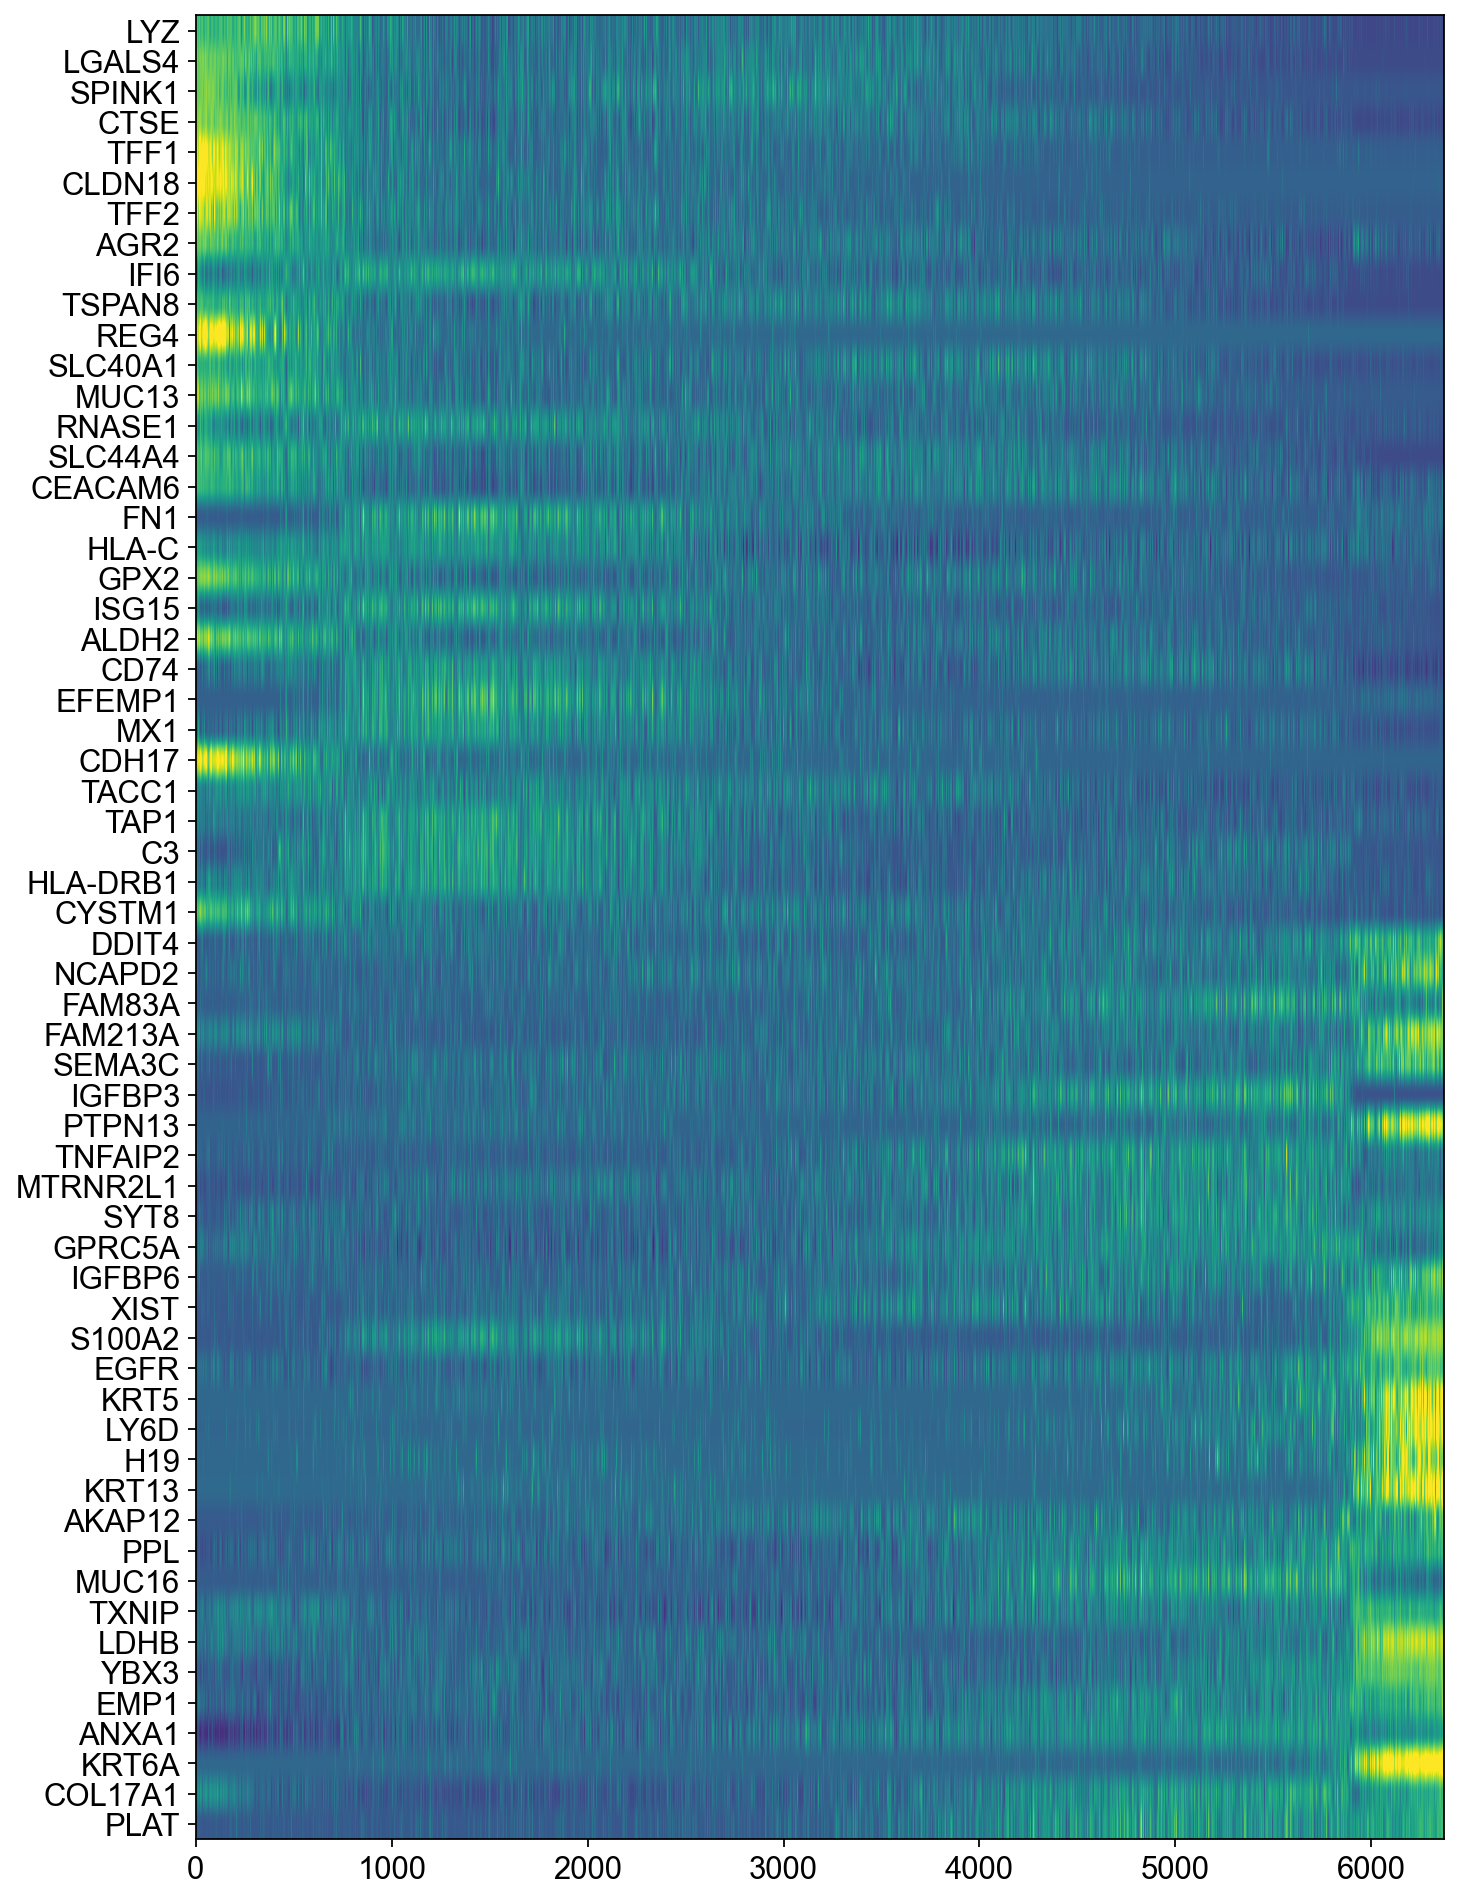

In [90]:

# the key is to scale this heatmap data!
# X axis is cells sorted by PC pc_idx (starting from 0) value
# Y axis is bottom n_bottom_top_genes and top n_bottom_top_genes genes by PC1 score
# this shows some MTRNR and RPS
X_pca_df = pd.DataFrame(scp1644_tumor.obsm['X_pca'], index=scp1644_tumor.obs_names)

pc_output = pd.DataFrame(scp1644_tumor.varm['PCs'], index=scp1644_tumor.var_names)

pc_idx = 2
n_bottom_top_genes = 30
bottom_top_genes = list(pc_output.sort_values(pc_idx).index[:n_bottom_top_genes]) + list(pc_output.sort_values(pc_idx).index[-n_bottom_top_genes:])
data = sc.pp.scale(scp1644_tumor[X_pca_df.sort_values(pc_idx).index, bottom_top_genes].X).T
print(data.min(), data.max())
fig, ax = plt.subplots(figsize=(10, 15))
im = ax.imshow(data, aspect='auto', vmin=-2, vmax=3)
ax.set_yticks(range(len(bottom_top_genes)), bottom_top_genes)
ax.grid(None)


-1.7284273 26.731035


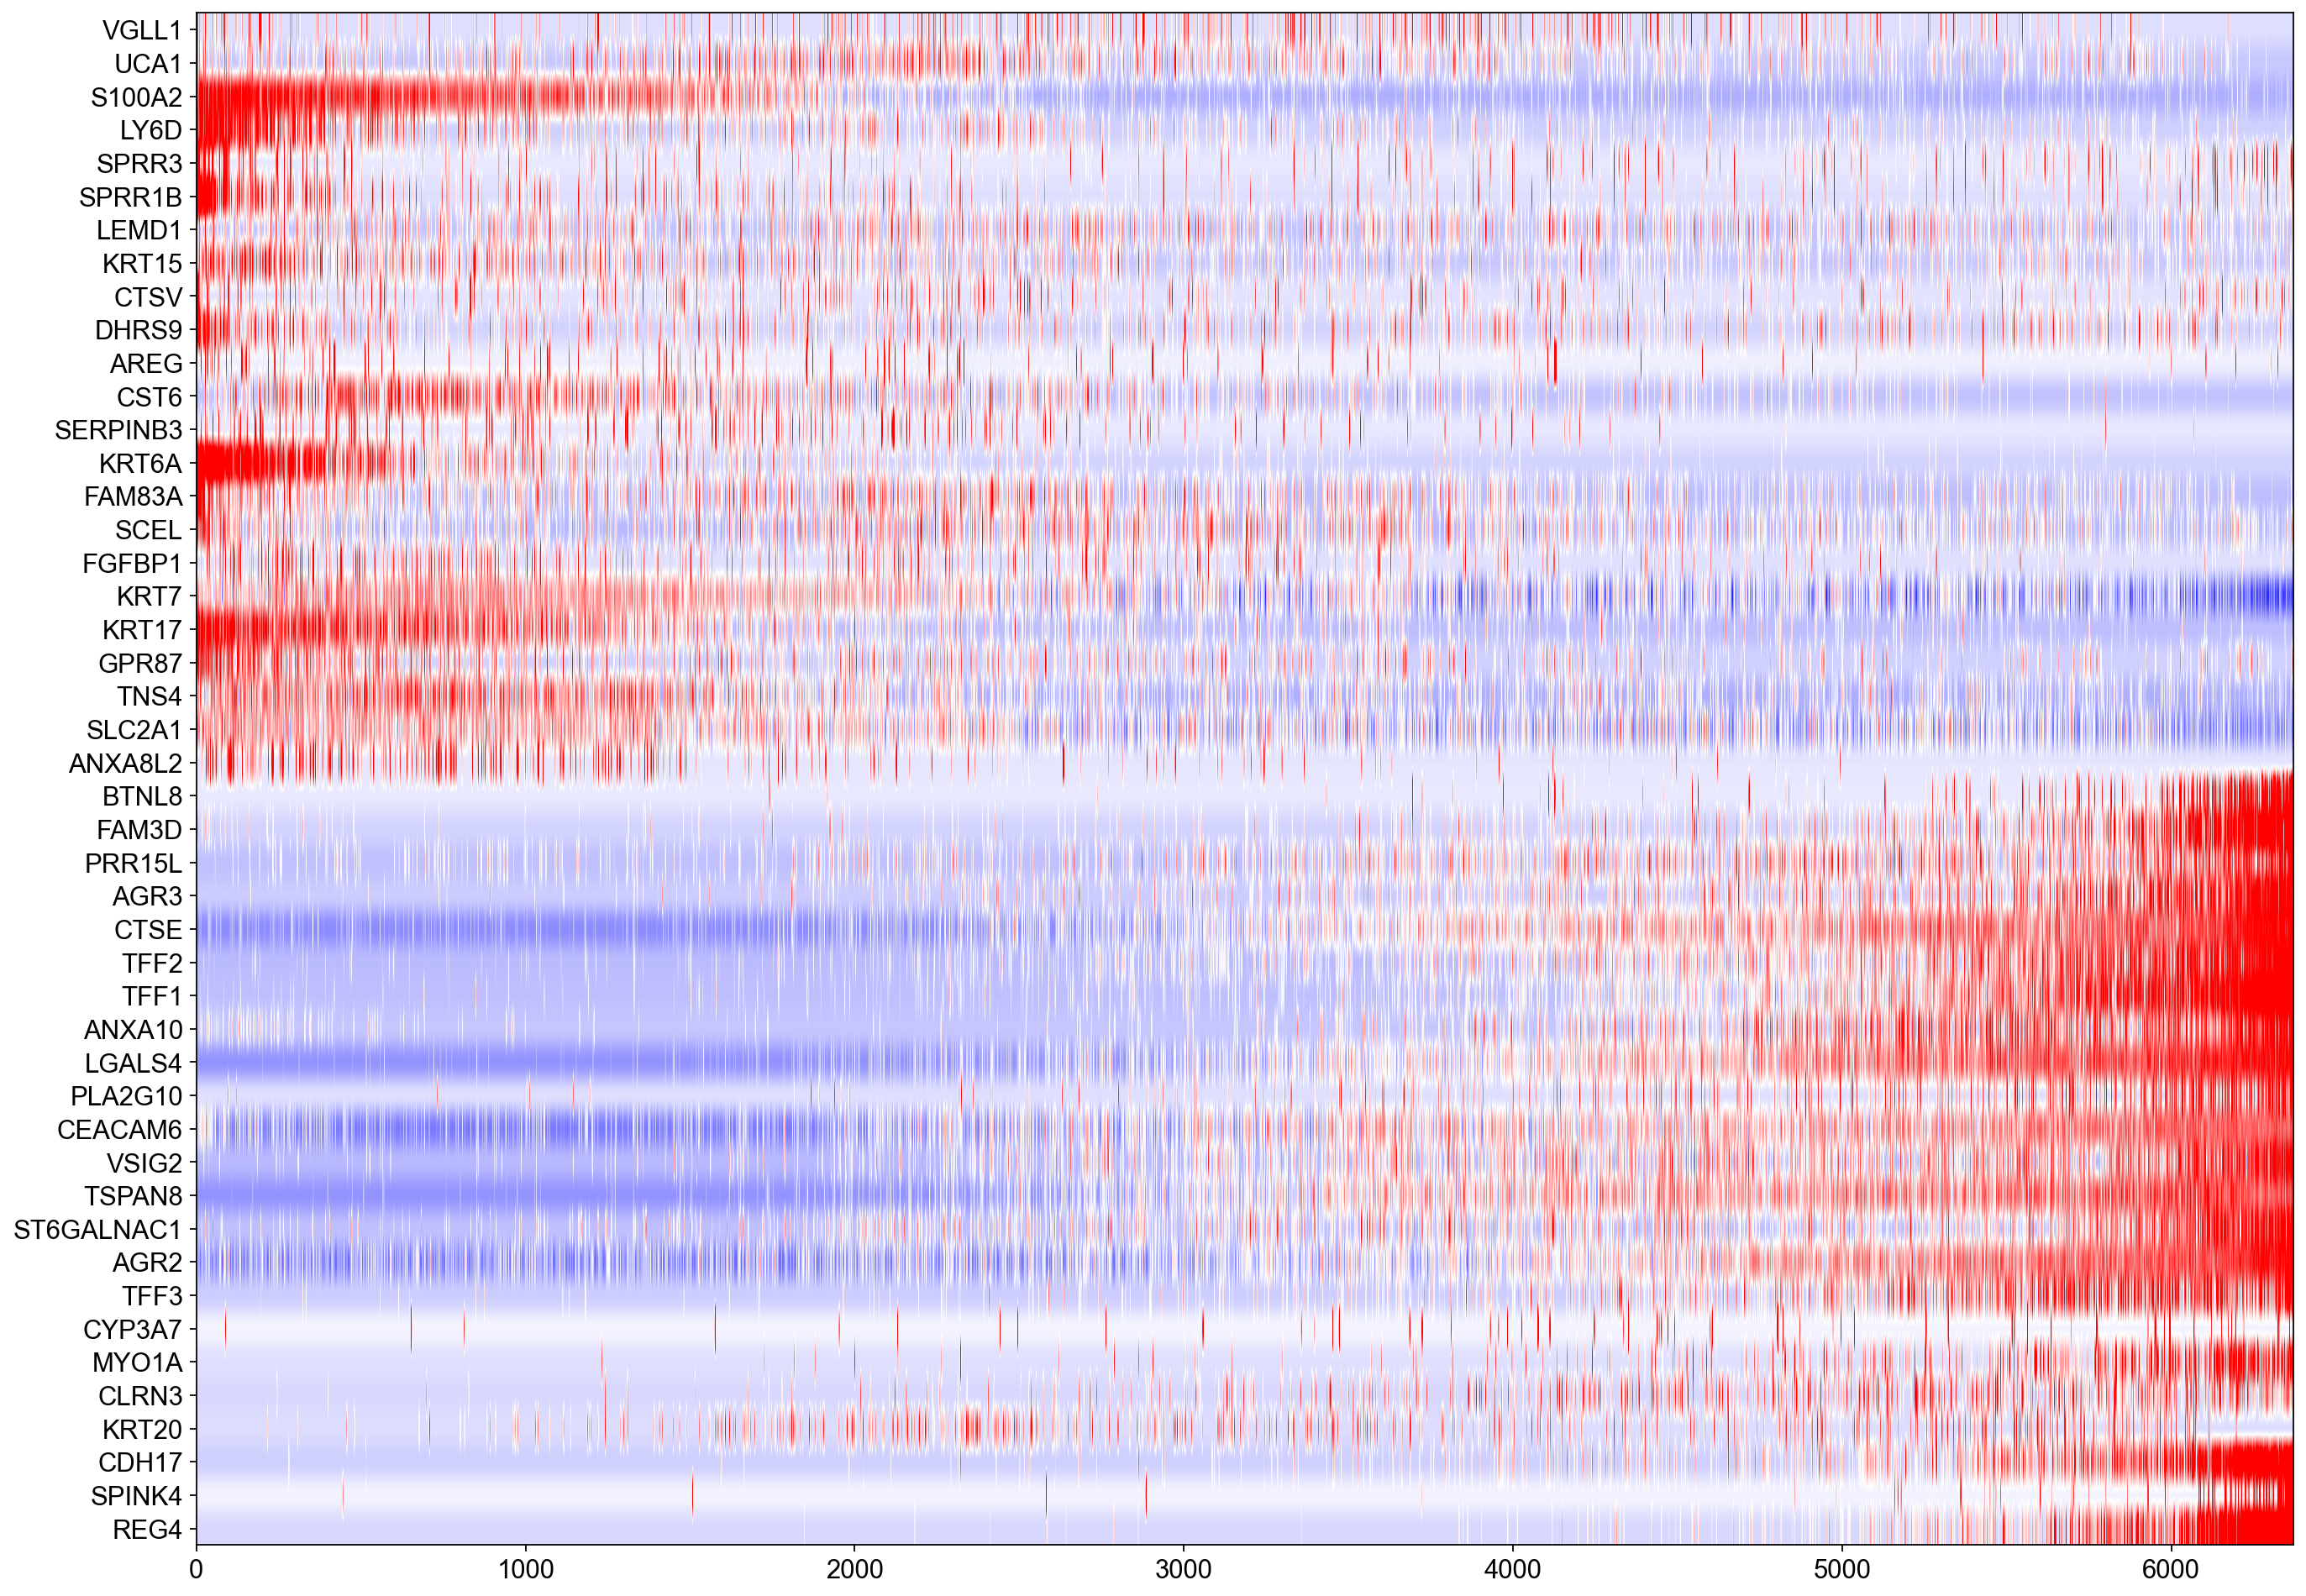

In [91]:
import itertools
moffitt_labels = list(itertools.chain(*mship.moffitt_pdac.values()))


# the key is to scale this heatmap data!
# X axis is cells sorted by PC pc_idx (starting from 0) value
# Y axis is bottom n_bottom_top_genes and top n_bottom_top_genes genes by PC1 score
# this shows some MTRNR and RPS
# X_pca_df = pd.DataFrame(scp1644_tumor.obsm['X_pca'], index=scp1644_tumor.obs_names)

# pc_output = pd.DataFrame(scp1644_tumor.varm['PCs'], index=scp1644_tumor.var_names)
#
# pc_idx = 2
# n_bottom_top_genes = 30
# bottom_top_genes = list(pc_output.sort_values(pc_idx).index[:n_bottom_top_genes]) + list(pc_output.sort_values(pc_idx).index[-n_bottom_top_genes:])
data = sc.pp.scale(scp1644_tumor[scp1644_tumor.obs.score_difference.sort_values().index, moffitt_labels].X).T
print(data.min(), data.max())
fig, ax = plt.subplots(figsize=(20, 15))
im = ax.imshow(data, aspect='auto', vmin=-2, vmax=2, cmap='bwr')
ax.set_yticks(range(len(moffitt_labels)), moffitt_labels)
ax.grid(None)


-1.7284273 26.731035


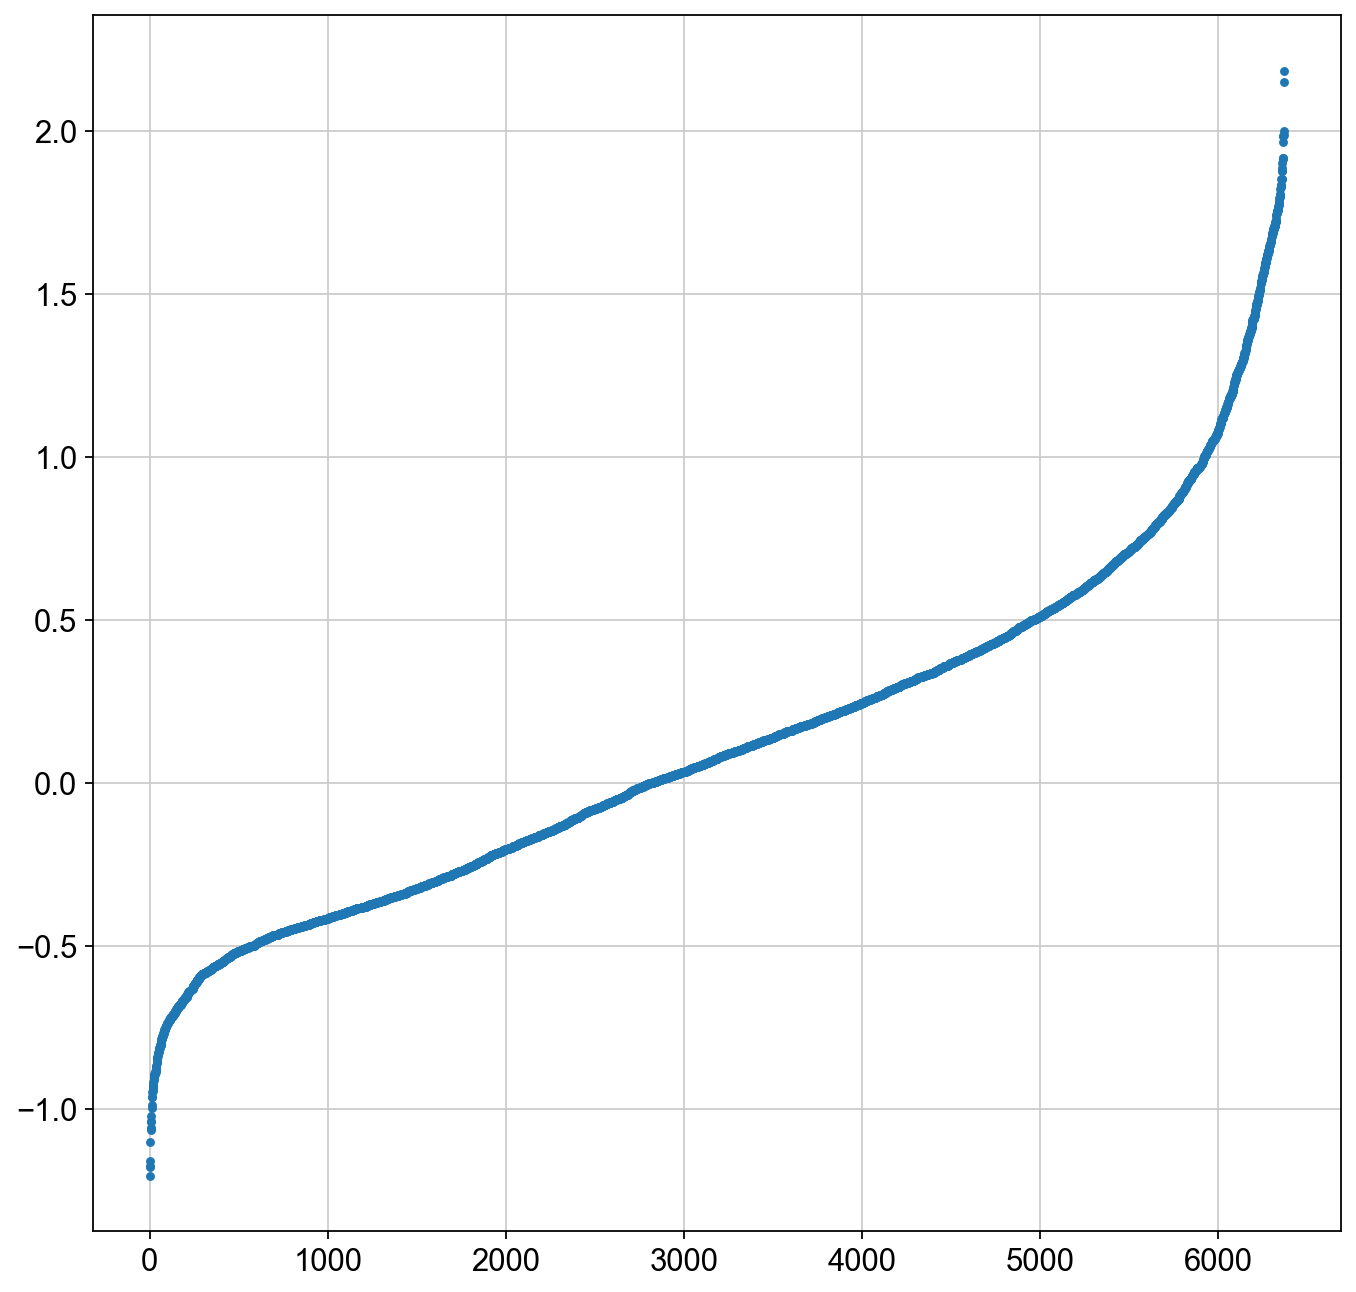

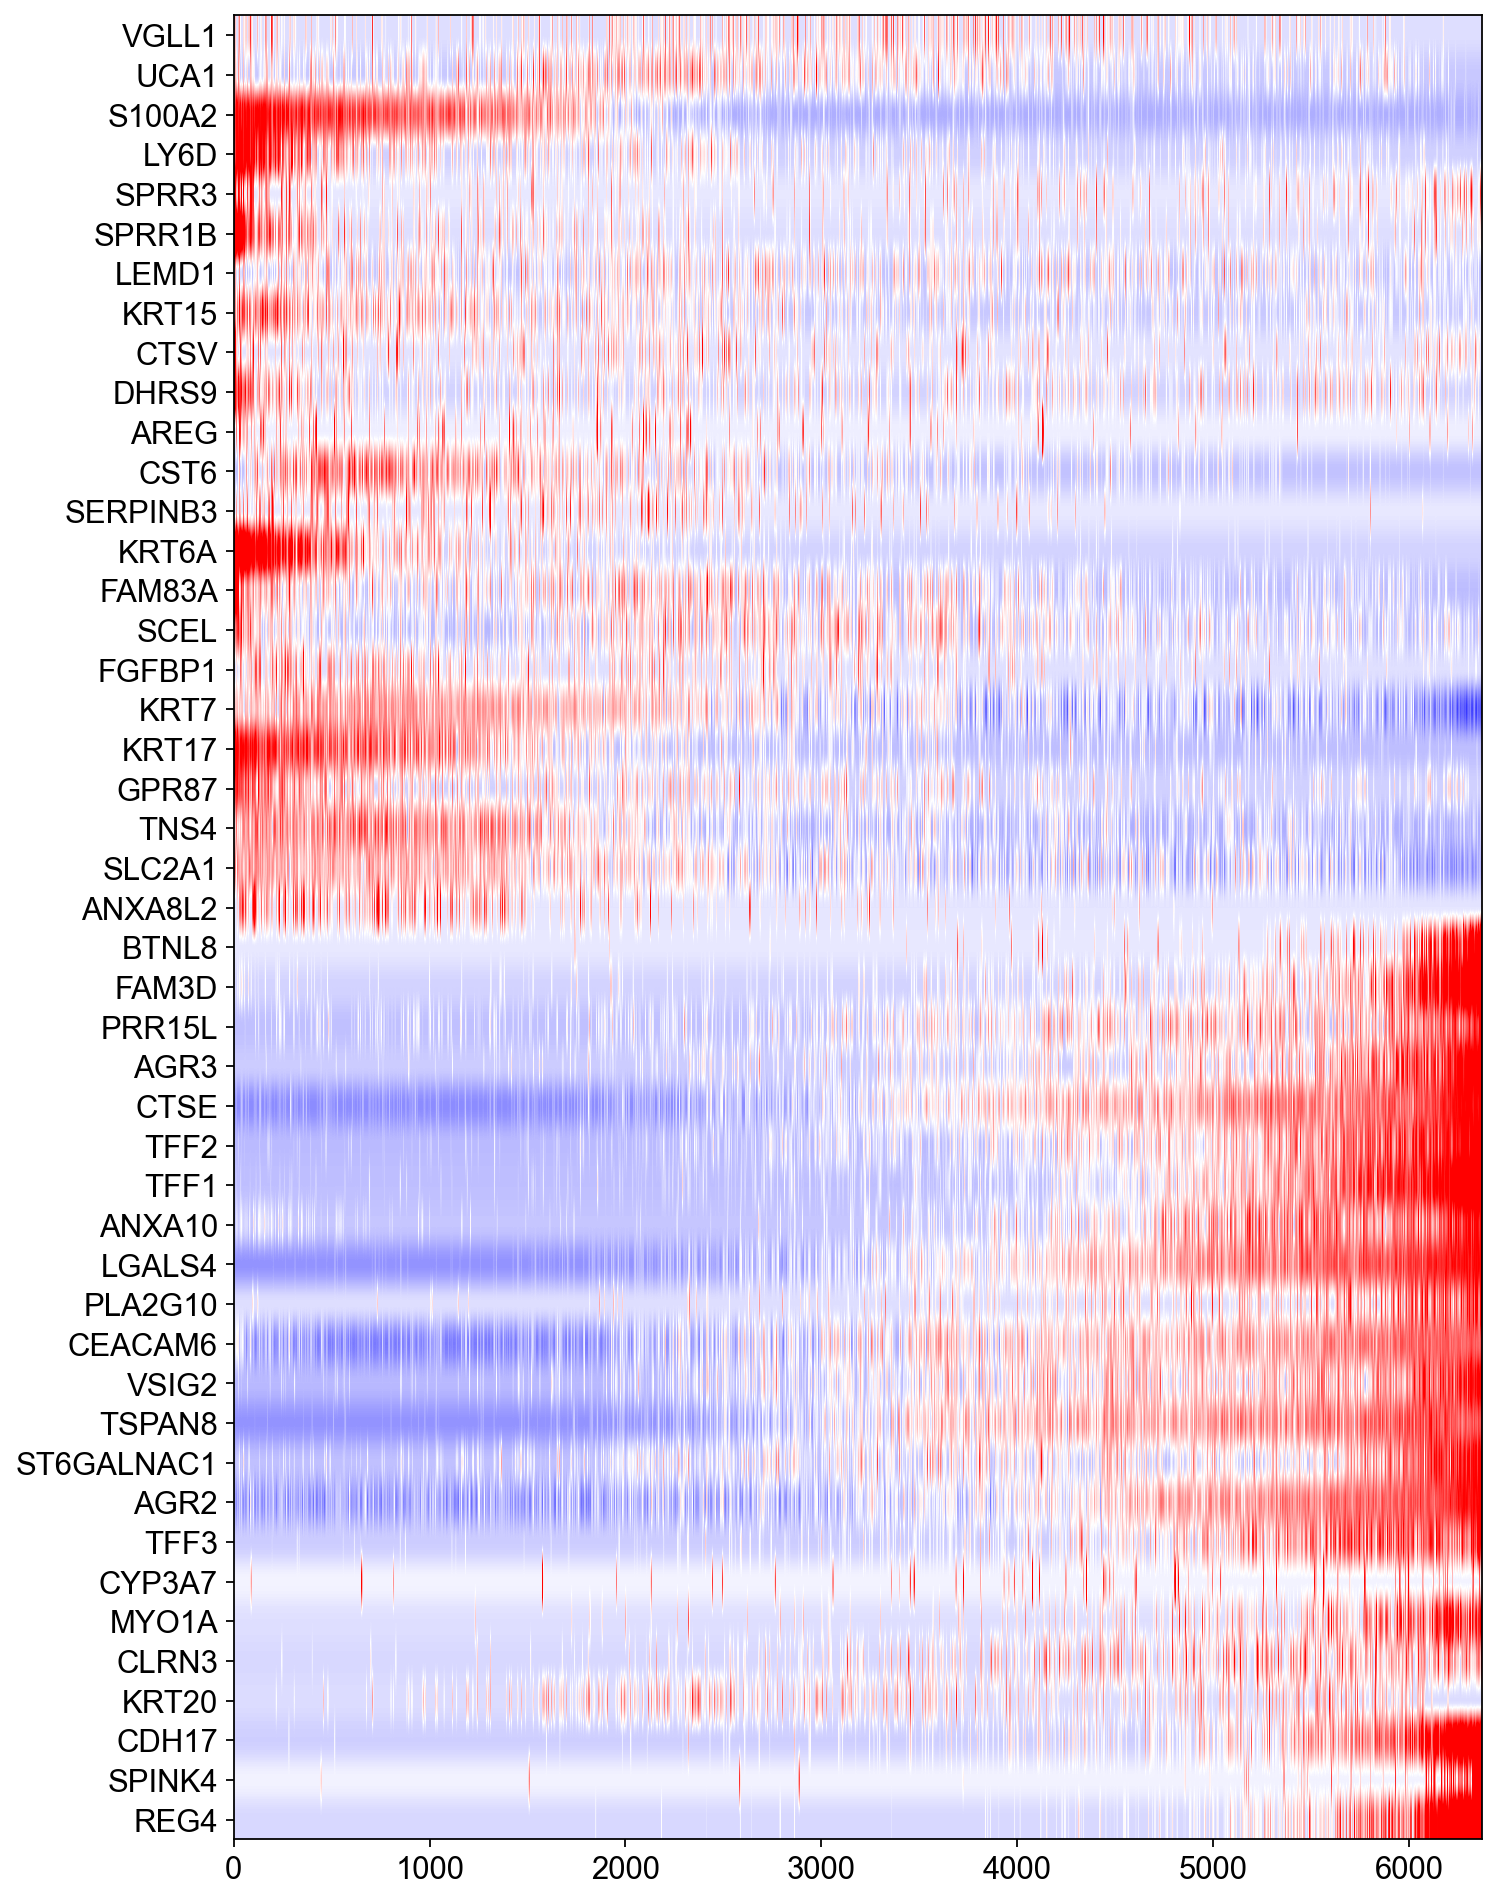

In [92]:
import itertools
moffitt_labels = list(itertools.chain(*mship.moffitt_pdac.values()))
score_diff_index = scp1644_tumor.obs.score_difference.sort_values().index


plt.plot(scp1644_tumor.obs.score_difference[score_diff_index].values, '.')

# the key is to scale this heatmap data!
# X axis is cells sorted by PC pc_idx (starting from 0) zzvalue
# Y axis is bottom n_bottom_top_genes and top n_bottom_top_genes genes by PC1 score
# this shows some MTRNR and RPS
# X_pca_df = pd.DataFrame(scp1644_tumor.obsm['X_pca'], index=scp1644_tumor.obs_names)

# pc_output = pd.DataFrame(scp1644_tumor.varm['PCs'], index=scp1644_tumor.var_names)
#
# pc_idx = 2
# n_bottom_top_genes = 30
# bottom_top_genes = list(pc_output.sort_values(pc_idx).index[:n_bottom_top_genes]) + list(pc_output.sort_values(pc_idx).index[-n_bottom_top_genes:])
data = sc.pp.scale(scp1644_tumor[scp1644_tumor.obs.score_difference.sort_values().index, moffitt_labels].X).T
print(data.min(), data.max())
fig, ax = plt.subplots(figsize=(10, 15))
im = ax.imshow(data, aspect='auto', vmin=-2, vmax=2, cmap='bwr')
ax.set_yticks(range(len(moffitt_labels)), moffitt_labels)
ax.grid(None)


0.81097617770943 0.0007378797604854492
0.81097617770943 0.0007378797604854492
0.572924994856745
0.4051191489744722
0.40585702873495777 0.40585702873495766
0.4058570287349577
0.572924994856745


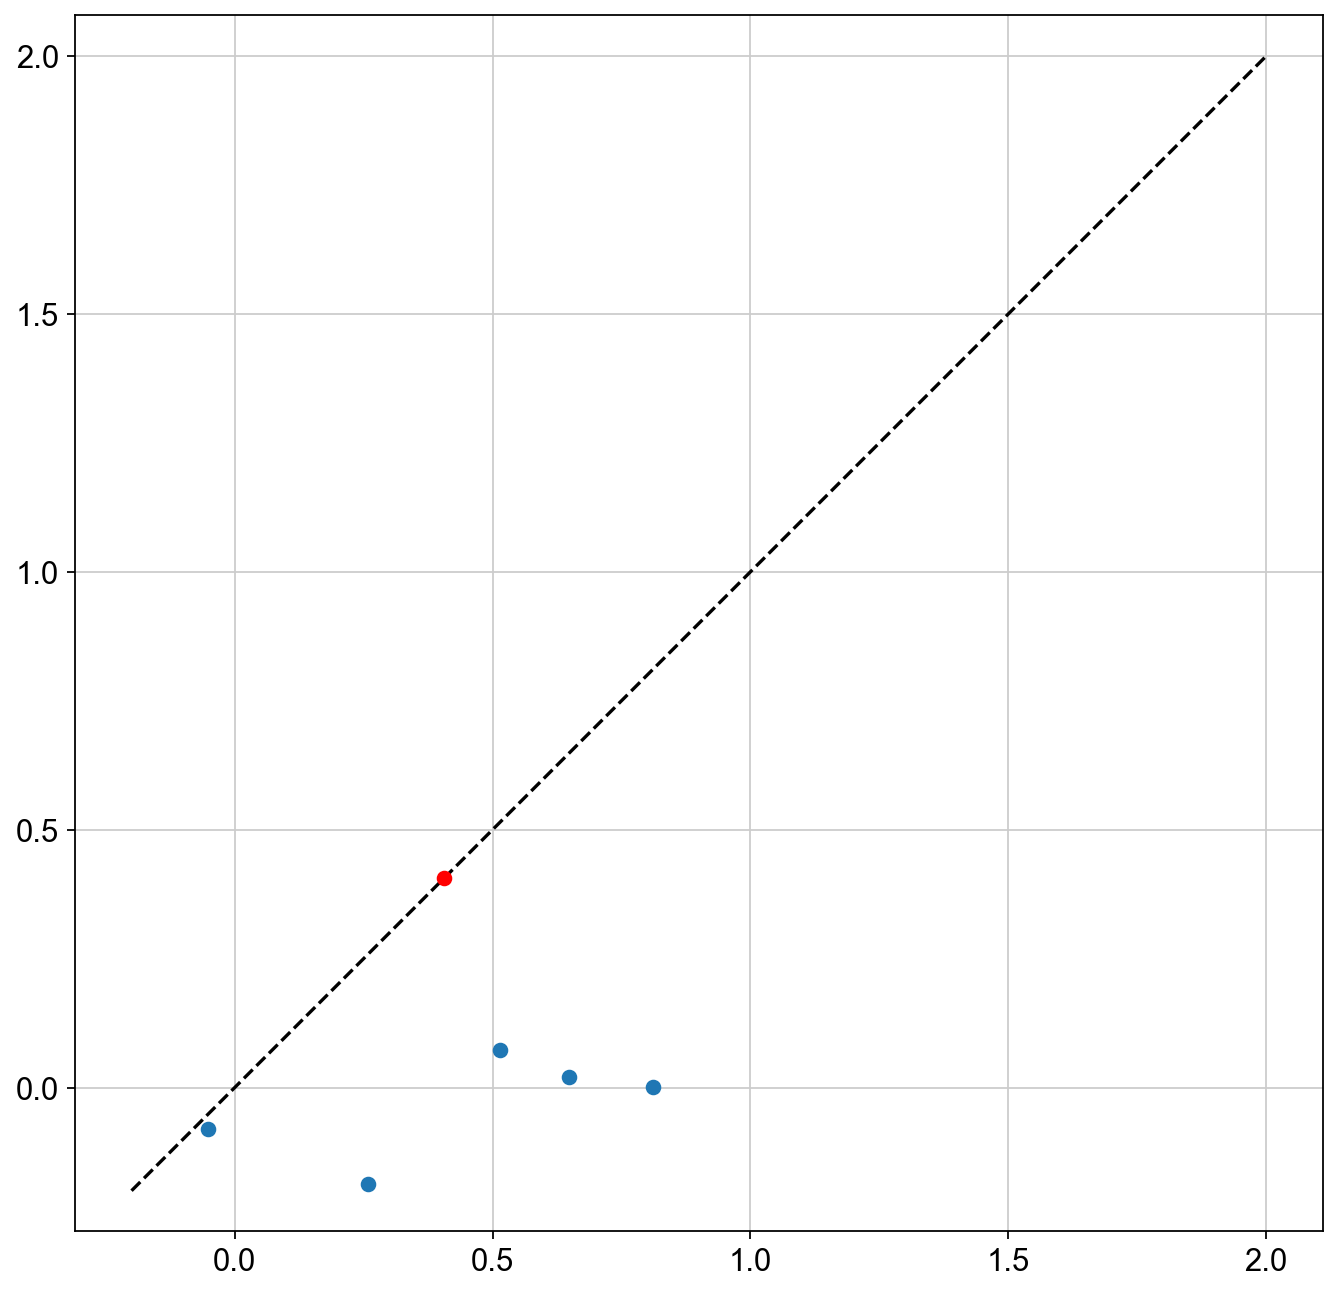

In [136]:
idx = 4
plt.plot([-0.2, 2.0], [-0.2, 2.0], 'k--')
plt.plot(scp1644_tumor.obs.classical_score[:5], scp1644_tumor.obs.basal_score[:5], 'o')

print(scp1644_tumor.obs.classical_score[idx], scp1644_tumor.obs.basal_score[idx])
print(scp1644_tumor.obs.classical_score[idx], scp1644_tumor.obs.basal_score[idx])
# print((scp1644_tumor.obs.classical_score[idx] - )**2 + (scp1644_tumor.obs.basal_score[idx])**2)

# the horizontal distance to x=y is x-y
# the vertical distance to x=y is y-x
dist_est = np.power(((scp1644_tumor.obs.classical_score[idx] - scp1644_tumor.obs.basal_score[idx])**2 + (scp1644_tumor.obs.basal_score[idx]-scp1644_tumor.obs.classical_score[idx])**2), 0.5)/2
xy_factor = (dist_est) / (math.sqrt(2))
print(dist_est)
print(xy_factor)

print(scp1644_tumor.obs.classical_score[idx]-xy_factor, scp1644_tumor.obs.basal_score[idx]+xy_factor)
plt.plot(scp1644_tumor.obs.classical_score[idx]-xy_factor, scp1644_tumor.obs.basal_score[idx]+xy_factor, 'ro')
plt.axis('equal')

# another way to calculate it
score_avg = (scp1644_tumor.obs.classical_score[idx] + scp1644_tumor.obs.basal_score[idx])/2
print(score_avg)
print(math.sqrt((score_avg - scp1644_tumor.obs.classical_score[idx])**2 + (score_avg - scp1644_tumor.obs.classical_score[idx])**2))

dist_est_buf = []
for idx in range(len(scp1644_tumor.obs.classical_score)):
    dist_est_buf.append(np.power(((scp1644_tumor.obs.classical_score[idx] - scp1644_tumor.obs.basal_score[idx])**2 + (scp1644_tumor.obs.basal_score[idx]-scp1644_tumor.obs.classical_score[idx])**2), 0.5)/2)

scp1644_tumor.obs['IC_dist_est'] = dist_est_buf

Figure S3C


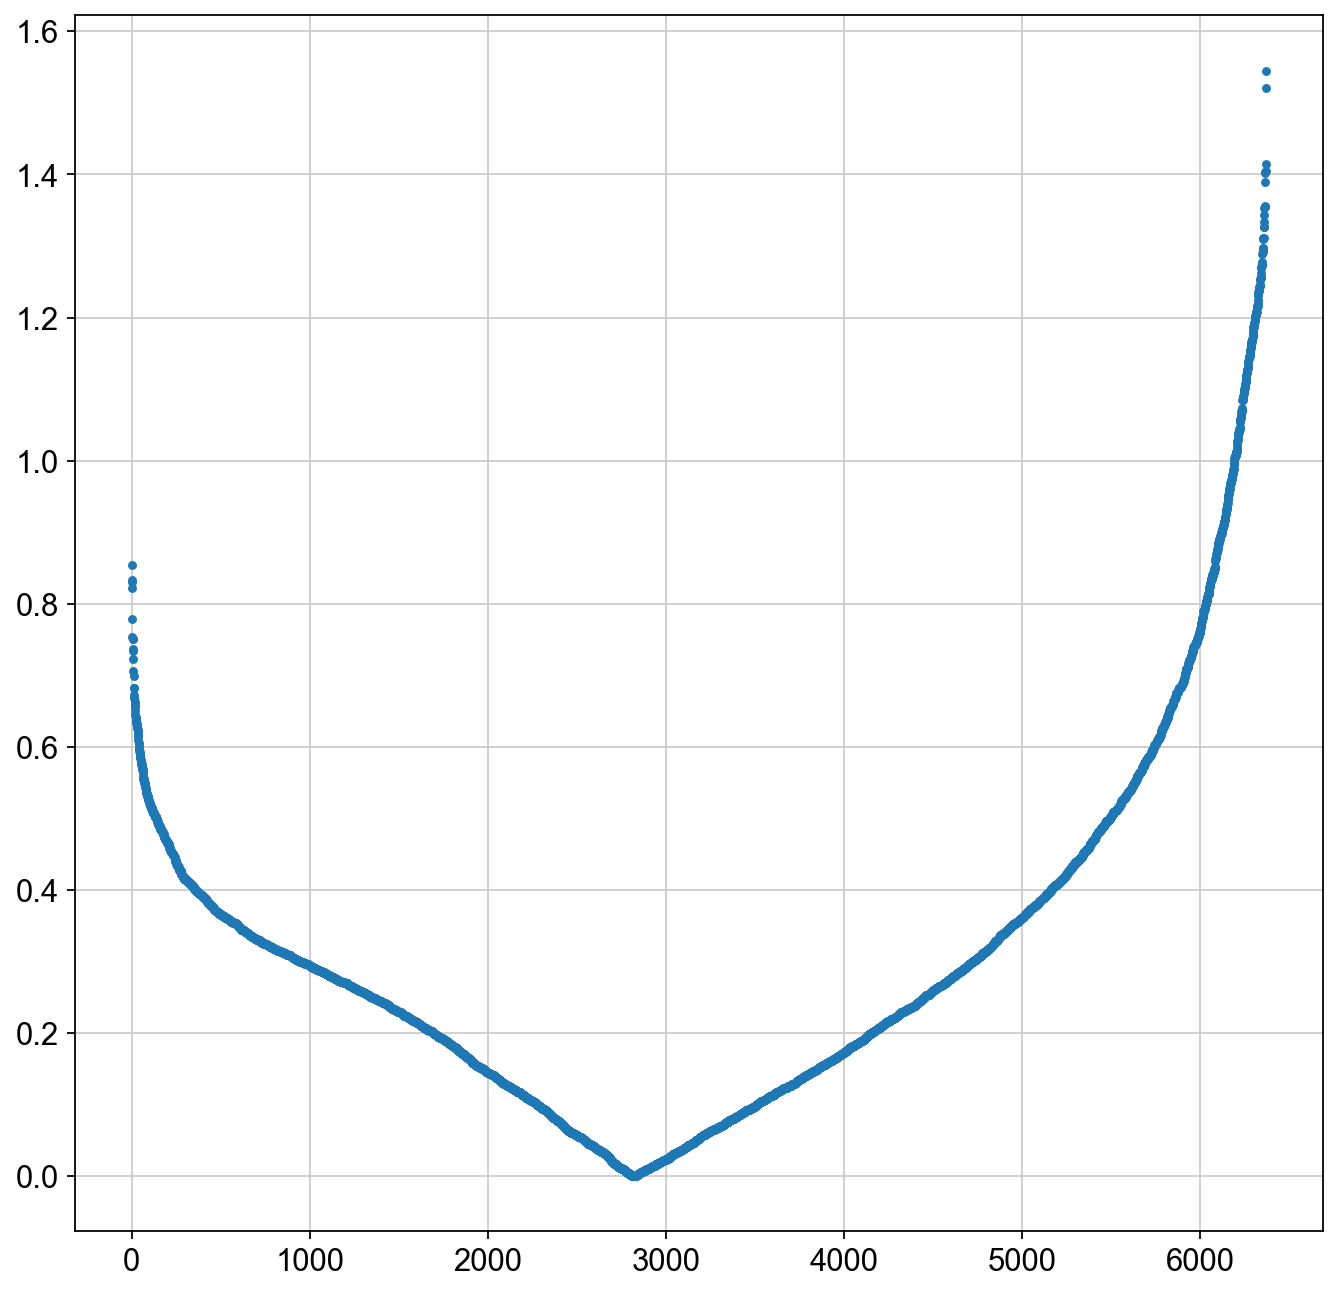

In [145]:
print("Figure S3C")
plt.plot(scp1644_tumor.obs.IC_dist_est[score_diff_index].values, '.')
# plt.axis('equal')